### 简单计算排列组合中的组合数

In [161]:
from scipy.special import comb  # 导入组合数计算函数 comb

In [162]:
comb(3, 2), comb(5, 2)  # 计算组合数：C(3,2)=3，C(5,2)=10

(np.float64(3.0), np.float64(10.0))

In [163]:
v_sum = 0  # 用于累计“多数模型预测正确”的总概率
for i in range(101, 200 + 1, 1):  # 200 个模型中，至少 101 个预测正确时，多数投票结果才正确
    # comb(200, i)：从200个模型中选出i个预测正确；0.6 ** i：i个模型预测正确的概率；0.4 ** (200 - i)：其余模型预测错误的概率
    v_sum += comb(200, i) * (0.6 ** i) * (0.4 ** (200 - i))
v_sum

np.float64(0.9973645966438958)

### 数据集

In [164]:
import numpy as np
import matplotlib.pyplot as plt

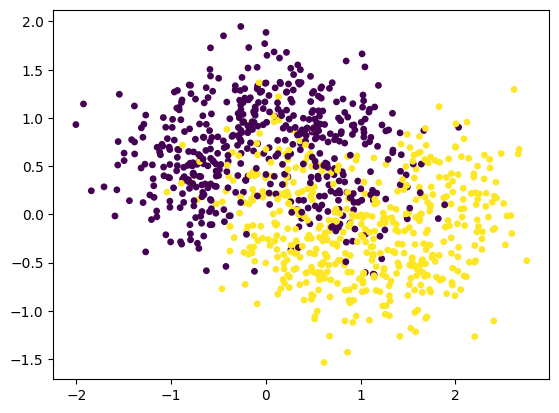

In [165]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.4, random_state=20)
plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
plt.show()

In [166]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

### Bagging

In [167]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [168]:
bagging = BaggingClassifier(             # 创建 Bagging 分类模型
    estimator=DecisionTreeClassifier(),  # 基学习器：决策树
    n_estimators=100,                    # 一共训练 100 个子模型
    max_samples=500,                     # 每个子模型抽取 500 个训练样本
    bootstrap=True,                      # 有放回抽样（Bootstrap）
    n_jobs=-1
)
bagging.fit(X_train, y_train)
bagging.score(X_test, y_test)

0.844

### OOB

In [169]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=500,
    oob_score=True,     # 启用袋外样本 OOB 评估
    bootstrap=True,     # 有放回抽样，OOB 必须配合 bootstrap=True
    n_jobs=-1
)
bagging.fit(X, y)
bagging.oob_score_      # 查看 OOB 准确率

0.831